# Kwant — Theory and Practice · Chapter 5
## Spectral densities by KPM and symbolic Hamiltonians with `kwant.continuum`

*Part I · Sections 12–13 · Figures 24–28* &nbsp;·&nbsp; [← Chapter 4](04_Observables_and_Visualisation.ipynb) · [Contents](00_Contents.ipynb) · [Chapter 6 →](06_Magnetic_Fields.ipynb)

### In this chapter

- [12. The Kernel Polynomial Method — spectral densities without diagonalisation](#12.-The-Kernel-Polynomial-Method-—-spectral-densities-without-diagonalisation)
    - [Why](#Why)
    - [How](#How)
    - [API](#API)
- [13. `kwant.continuum` — symbolic Hamiltonians, discretised automatically](#13.-kwant.continuum-—-symbolic-Hamiltonians,-discretised-automatically)
    - [What the discretiser knows](#What-the-discretiser-knows)
    - [Worked example: the BHZ model](#Worked-example:-the-BHZ-model)

Run the **Setup** cell first: it imports Kwant, reports the sparse solver, mutes three library warnings and defines `show_fig`, whose figure counter continues the course-wide numbering. Each chapter is self-contained given its Setup cell (a *carried over* cell, where present, rebuilds an object defined in an earlier chapter). Installation, the `kwant` kernel and the conventions are in [`00_Contents.ipynb`](00_Contents.ipynb).

`SPDX-License-Identifier: Apache-2.0` — Copyright 2026 Fabio Campolim.


In [1]:
# --- Setup: run this cell first ----------------------------------------------
# Imports, the sparse-solver report, three muted library warnings, and the
# figure helper.  Every chapter of the course starts with this cell.
import kwant
import numpy as np
import scipy
import tinyarray as ta                   # noqa: F401  (used by later cells)
import matplotlib
from matplotlib import pyplot

print("kwant", kwant.__version__, "| numpy", np.__version__,
      "| scipy", scipy.__version__, "| matplotlib", matplotlib.__version__)

# Which sparse solver is active? MUMPS is much faster than SciPy's SuperLU.
import kwant.solvers.default
print("default solver:", kwant.solvers.default.__name__)
try:
    import kwant.solvers.mumps          # noqa: F401
    print("MUMPS available: yes")
except ImportError:
    print("MUMPS available: no  (falling back to scipy sparse -> slower)")

matplotlib.rcParams['figure.figsize'] = (7, 5)

# Mute three library warnings that are not ours to fix and would otherwise be
# printed under some figures.  Done by wrapping warnings.showwarning rather than
# with warnings.filterwarnings(), because kwant.plotter calls
# warnings.resetwarnings() on every 3D plot, which silently deletes all user
# filters (reported upstream).  Only these three messages are muted:
#  * kwant 1.5.0's 3D plotter calls a matplotlib function deprecated in 3.10
#    (fixed on Kwant's main branch, unreleased);
#  * mpmath (via sympy) uses a deprecated bitcount helper;
#  * kwant.plotter.map notes that a few density values exceed the colour range,
#    which is expected for the delta-like densities in sections 6 and 12.
import warnings
_MUTED = ('proj_transform_clip', 'bitcount function is deprecated', 'overflowing upper limit')
_showwarning = warnings.showwarning

def _quiet_showwarning(message, category, filename, lineno, file=None, line=None):
    if not any(k in str(message) for k in _MUTED):
        _showwarning(message, category, filename, lineno, file, line)

warnings.showwarning = _quiet_showwarning

# --- Figure helper ------------------------------------------------------------
# Every figure ends with show_fig("..."), which stamps an auto-numbered italic
# caption under the figure and then shows it.  Figures are numbered
# continuously across the chapters of the course: this chapter's figures are
# 24–28, so the counter starts at 23.  (Re-running a single cell out of
# order advances it -- harmless, but numbers shift.)
_FIG_NO = [23]

def show_fig(caption=None):
    if caption:
        _FIG_NO[0] += 1
        fig = pyplot.gcf()
        fig.text(0.5, -0.02, f"Figure {_FIG_NO[0]}: {caption}",
                 ha='center', va='top', fontsize=9, style='italic',
                 wrap=True, transform=fig.transFigure)
    pyplot.show()


kwant 1.5.0 | numpy 2.5.1 | scipy 1.18.0 | matplotlib 3.10.7
default solver: kwant.solvers.default
MUMPS available: yes


---
## 12. The Kernel Polynomial Method — spectral densities without diagonalisation

### Why

Diagonalising a sparse $N\times N$ Hamiltonian costs $O(N^3)$ in the worst case. But often
you do not want eigenvectors — you want the **density of states**, a local DOS, or a
conductivity. KPM gets those in $O(N)$ per moment, for systems with millions of sites.

### How

**Step 1 — rescale.** Chebyshev polynomials $T_n(x) = \cos(n \arccos x)$ live on
$[-1,1]$, so rescale $H \to \tilde H = (H - b)/a$ with the spectrum inside $(-1,1)$.

**Step 2 — expand.** Any spectral function is expanded as
$$\rho(E) = \frac{1}{\pi\sqrt{1-E^2}}\left(\mu_0 + 2\sum_{n=1}^{N-1} \mu_n T_n(E)\right),
\qquad \mu_n = \operatorname{Tr}\big[T_n(\tilde H)\big].$$

**Step 3 — iterate.** The Chebyshev recurrence
$$T_{n+1}(\tilde H)\lvert v\rangle = 2\tilde H\,T_n(\tilde H)\lvert v\rangle - T_{n-1}(\tilde H)\lvert v\rangle$$
means each moment costs **one sparse matrix–vector product**. No factorisation, no storage
beyond two vectors.

**Step 4 — stochastic trace.** The trace is estimated with random vectors $\lvert r\rangle$
with random phases: $\operatorname{Tr}A \approx \frac{1}{R}\sum_r \langle r\rvert A \lvert r\rangle$,
with relative error $\sim 1/\sqrt{RN}$. Large systems need *fewer* random vectors — the
self-averaging is the point.

**Step 5 — kernel.** Truncating the series at $N$ moments causes Gibbs oscillations.
Multiplying $\mu_n$ by a **kernel** $g_n$ (Jackson by default) suppresses them, at the cost
of broadening features to resolution $\sim a\pi/N$. **More moments = finer energy
resolution**; more random vectors = less statistical noise. They are separate knobs.

### API

```python
spectrum = kwant.kpm.SpectralDensity(fsyst, num_moments=..., num_vectors=...)
energies, densities = spectrum()          # the DOS
spectrum.add_moments(100)                 # refine resolution, reuses work
spectrum.add_vectors(5)                   # reduce noise
spectrum.integrate(distribution_function=fermi)   # e.g. total particle number
```

For **local** DOS, replace the random vectors with vectors localised on the sites of
interest via `vector_factory=kwant.kpm.LocalVectors(fsyst, where)` and `mean=False`.

**Why Chebyshev.**  KPM expands $\delta(E-H)$ in Chebyshev polynomials
$T_n(H)$, evaluated by sparse matrix-vector products only — $\mathcal{O}(N)$
per moment, no diagonalisation.  Truncating the series produces Gibbs
oscillations; multiplying the moments by the *Jackson kernel* damps them at
the cost of an energy resolution $\sim \Delta E/N_{\rm moments}$ (exercise
1.9).  The stochastic trace over random vectors converges as
$1/\sqrt{N_{\rm vec} N}$ — huge systems are actually *easier*.  *Further
reading:* Weisse, Wellein, Alvermann & Fehske, RMP **78**, 275 (2006).


sites: 6493


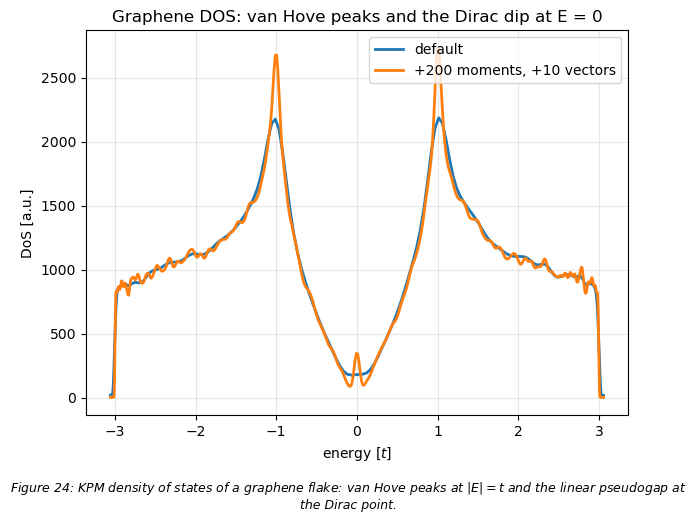

In [2]:
# --- DOS of a graphene flake by KPM ------------------------------------------
import kwant, kwant.kpm, numpy as np
from matplotlib import pyplot

def make_flake(r=30, t=-1, a=1, m=0.0):
    syst = kwant.Builder()
    lat = kwant.lattice.honeycomb(a, norbs=1)
    def circle(pos):
        x, y = pos
        return x**2 + y**2 < r**2
    syst[lat.a.shape(circle, (0, 0))] =  m      # staggered on-site (m != 0 opens a gap)
    syst[lat.b.shape(circle, (0, 0))] = -m
    syst[lat.neighbors()] = t
    syst.eradicate_dangling()
    return syst

fsyst_kpm = make_flake().finalized()
print("sites:", len(fsyst_kpm.sites))

spectrum = kwant.kpm.SpectralDensity(fsyst_kpm)
energies, densities = spectrum()

pyplot.plot(energies, densities.real, lw=2, label="default")

spectrum.add_moments(200)          # sharper energy resolution
spectrum.add_vectors(10)           # less stochastic noise
e2, d2 = spectrum()
pyplot.plot(e2, d2.real, lw=2, label="+200 moments, +10 vectors")

pyplot.xlabel("energy $[t]$"); pyplot.ylabel("DoS [a.u.]")
pyplot.title("Graphene DOS: van Hove peaks and the Dirac dip at E = 0")
pyplot.legend(); pyplot.grid(alpha=.3); show_fig(r'KPM density of states of a graphene flake: van Hove peaks at $|E|=t$ and the linear pseudogap at the Dirac point.')

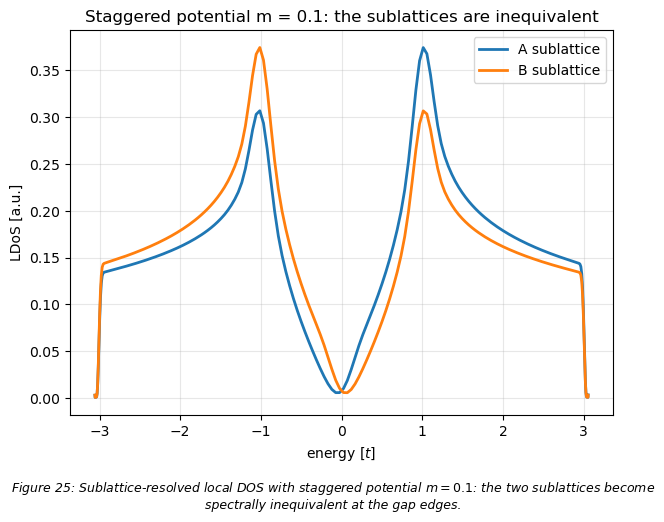

In [3]:
# --- Sublattice-resolved LOCAL density of states with LocalVectors -----------
import kwant.kpm, numpy as np
from matplotlib import pyplot

fsyst_stag = make_flake(m=0.1).finalized()

center_tag = np.array([0, 0])
where = lambda s: s.tag == center_tag           # the two atoms of the central cell

vector_factory = kwant.kpm.LocalVectors(fsyst_stag, where)
local_dos = kwant.kpm.SpectralDensity(fsyst_stag, num_vectors=None,
                                      vector_factory=vector_factory,
                                      mean=False)
energies, densities = local_dos()

pyplot.plot(energies, densities[:, 0].real, lw=2, label="A sublattice")
pyplot.plot(energies, densities[:, 1].real, lw=2, label="B sublattice")
pyplot.xlabel("energy $[t]$"); pyplot.ylabel("LDoS [a.u.]")
pyplot.title("Staggered potential m = 0.1: the sublattices are inequivalent")
pyplot.legend(); pyplot.grid(alpha=.3); show_fig(r'Sublattice-resolved local DOS with staggered potential $m=0.1$: the two sublattices become spectrally inequivalent at the gap edges.')

---
## 13. `kwant.continuum` — symbolic Hamiltonians, discretised automatically

Hand-discretising a $k\cdot p$ model is error-prone: sign conventions, symmetrisation of
terms like $k_x A(x) k_x$, and the factors of $i$ all bite. `kwant.continuum` does it
symbolically with SymPy.

```python
template = kwant.continuum.discretize('k_x**2 + k_y**2 + V(x, y)')
```

The result is a `Builder` **template** with translational symmetry in every direction — a
recipe, not a system. You then stamp it onto a shape:

```python
syst = kwant.Builder()
syst.fill(template, shape_function, start_point)
```

`fill` copies the template's on-site and hopping values onto every site of the region.
Leads are built the same way from the same template, which guarantees they match.

### What the discretiser knows

- $k_i \to$ symmetric finite differences; **$k_x A(x) k_x$ is discretised correctly**, not
  as $A k_x^2$.
- `identity(n)`, `kron(...)`, `sigma_0/x/y/z` are recognised, so multi-band models are natural.
- Coordinates `x, y, z` and arbitrary functions `V(x, y)` become Kwant parameters.
- `grid=a` sets the lattice constant.

### Worked example: the BHZ model

The Bernevig–Hughes–Zhang model of a HgTe quantum well is the canonical 2D topological
insulator:

$$H = C + M\sigma_0\tau_z - (B)(k_x^2+k_y^2)\sigma_0\tau_z - D(k_x^2+k_y^2)\sigma_0\tau_0
+ A k_x \sigma_z\tau_x - A k_y \sigma_0\tau_y$$

The sign of $M/B$ decides the phase. **Inverted** band ordering ($M/B > 0$) gives the
quantum spin Hall insulator: a bulk gap crossed by a pair of **helical edge states**,
counter-propagating and opposite-spin, protected by time reversal. That crossing is what
you will see in the band structure below, and the spin density map shows the two edges
carrying opposite spin.

`kwant.continuum.lambdify` gives you the *continuum* Hamiltonian as a callable, which is how
you check that the lattice model reproduces the continuum near $k=0$ — always do this.

**Where such Hamiltonians come from.**  Models like BHZ are $k\cdot p$
theory: an expansion of the band structure around a high-symmetry point in
a small set of bands, with symmetry dictating which terms may appear and
experiment (or ab initio) fixing the coefficients.  The discretiser then
turns the polynomial in $k$ into hoppings — the reverse of the
$\tan$-expansion of §1, sharing its accuracy limits.  *Further reading:*
Winkler (2003) for $k\cdot p$; Voon & Willatzen, *The k·p Method*
(Springer, 2009); BHZ, Science **314**, 1757 (2006).


In [4]:
# --- BHZ: symbolic model -> lattice system -> helical edge states ------------
import kwant, kwant.continuum, numpy as np
from matplotlib import pyplot

hamiltonian = """
   + C * identity(4) + M * kron(sigma_0, sigma_z)
   - B * (k_x**2 + k_y**2) * kron(sigma_0, sigma_z)
   - D * (k_x**2 + k_y**2) * kron(sigma_0, sigma_0)
   + A * k_x * kron(sigma_z, sigma_x)
   - A * k_y * kron(sigma_0, sigma_y)
"""

a = 20                                   # lattice constant in nm
template = kwant.continuum.discretize(hamiltonian, grid=a)
print(template)                          # inspect the generated tight-binding model

# Discrete coordinates: x y

# Onsite element:
_cache_0 = (
array([[-0.01+0.j,  0.  +0.j,  0.  +0.j,  0.  +0.j],
       [ 0.  +0.j,  0.01+0.j,  0.  +0.j,  0.  +0.j],
       [ 0.  +0.j,  0.  +0.j, -0.01+0.j,  0.  +0.j],
       [ 0.  +0.j,  0.  +0.j,  0.  +0.j,  0.01+0.j]]))
_cache_1 = (
array([[1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j]]))
_cache_2 = (
array([[-0.01+0.j,  0.  +0.j,  0.  +0.j,  0.  +0.j],
       [ 0.  +0.j, -0.01+0.j,  0.  +0.j,  0.  +0.j],
       [ 0.  +0.j,  0.  +0.j, -0.01+0.j,  0.  +0.j],
       [ 0.  +0.j,  0.  +0.j,  0.  +0.j, -0.01+0.j]]))
_cache_3 = (
array([[ 1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j, -1.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j, -1.+0.j]]))
_cache_4 = (
array([[0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j

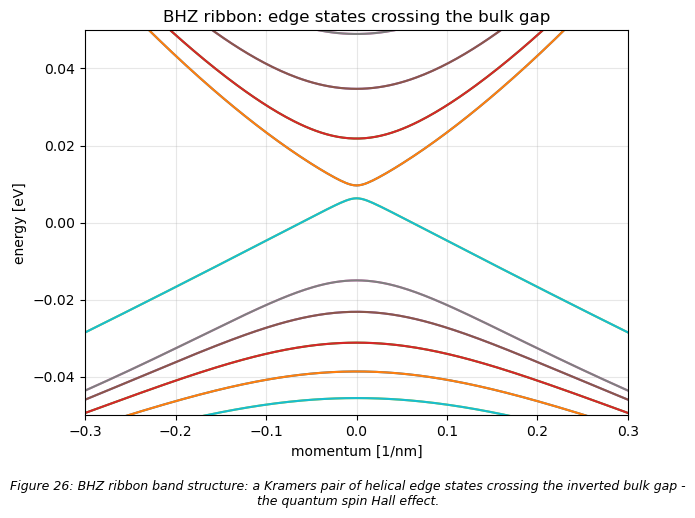

In [5]:
# --- Build a ribbon from the template ----------------------------------------
L, W = 2000, 1000                        # nm

def shape(site):
    x, y = site.pos
    return 0 <= y < W and 0 <= x < L

def lead_shape(site):
    x, y = site.pos
    return 0 <= y < W

syst = kwant.Builder()
syst.fill(template, shape, (0, 0))

lead = kwant.Builder(kwant.TranslationalSymmetry([-a, 0]))
lead.fill(template, lead_shape, (0, 0))

syst.attach_lead(lead)
syst.attach_lead(lead.reversed())
fbhz = syst.finalized()

params = dict(A=3.65, B=-68.6, D=-51.1, M=-0.01, C=0)   # inverted regime

kwant.plotter.bands(fbhz.leads[0], params=params,
                    momenta=np.linspace(-0.3, 0.3, 201), show=False)
pyplot.grid(alpha=.3)
pyplot.xlim(-.3, 0.3); pyplot.ylim(-0.05, 0.05)
pyplot.xlabel("momentum [1/nm]"); pyplot.ylabel("energy [eV]")
pyplot.title("BHZ ribbon: edge states crossing the bulk gap")
show_fig(r'BHZ ribbon band structure: a Kramers pair of helical edge states crossing the inverted bulk gap - the quantum spin Hall effect.')

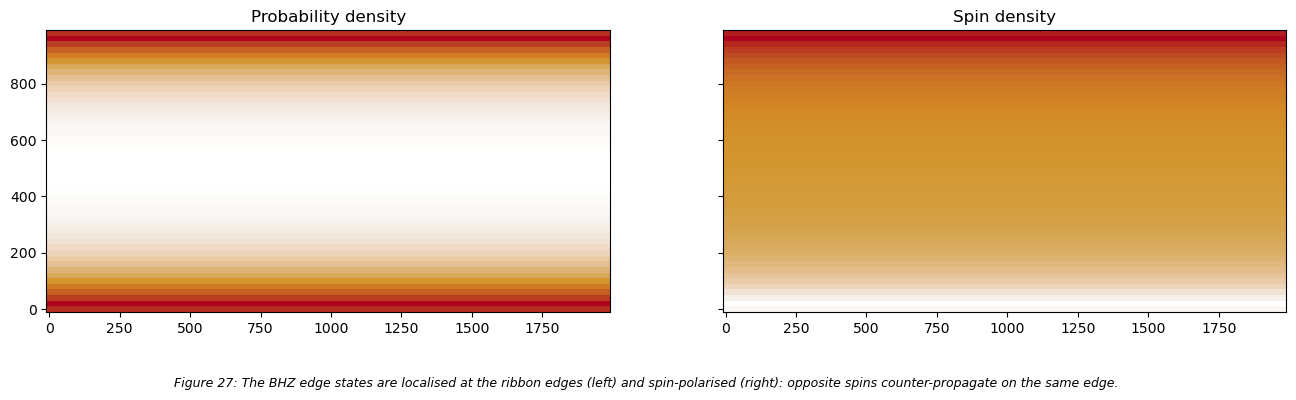

In [6]:
# --- Where do the edge states live, and what spin do they carry? -------------
wf = kwant.wave_function(fbhz, energy=0, params=params)

prob_density = kwant.operator.Density(fbhz, np.eye(4))
spin_density = kwant.operator.Density(fbhz, np.kron(np.array([[1, 0], [0, -1]]),
                                                    np.eye(2)))

wf_sqr = sum(prob_density(psi) for psi in wf(0))
rho_sz = sum(spin_density(psi) for psi in wf(0))

fig, (ax1, ax2) = pyplot.subplots(1, 2, sharey=True, figsize=(16, 4))
kwant.plotter.map(fbhz, wf_sqr, ax=ax1)
kwant.plotter.map(fbhz, rho_sz, ax=ax2)
ax1.set_title("Probability density"); ax2.set_title("Spin density")
show_fig(r'The BHZ edge states are localised at the ribbon edges (left) and spin-polarised (right): opposite spins counter-propagate on the same edge.')

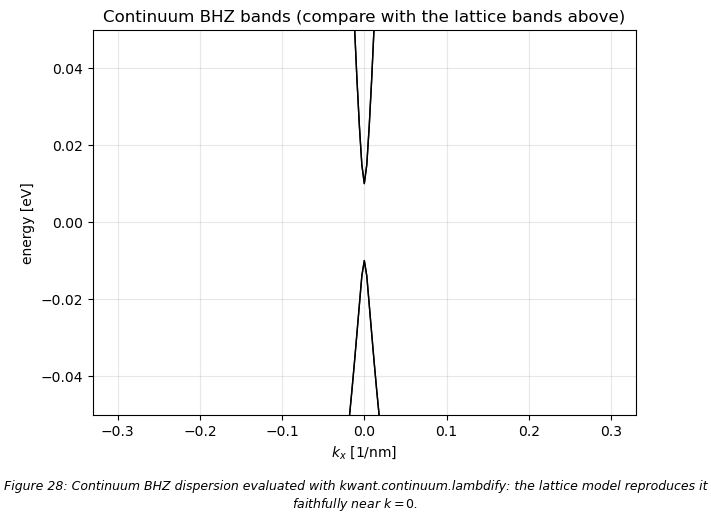

In [7]:
# --- Sanity check: does the lattice model match the continuum near k = 0? ----
import kwant.continuum

h_k = kwant.continuum.lambdify(hamiltonian, locals=params)
k_cont = np.linspace(-0.3, 0.3, 201)
e_cont = [np.linalg.eigvalsh(h_k(k_x=k, k_y=0)) for k in k_cont]

pyplot.plot(k_cont, e_cont, 'k-', lw=1)
pyplot.ylim(-0.05, 0.05); pyplot.xlabel("$k_x$ [1/nm]"); pyplot.ylabel("energy [eV]")
pyplot.title("Continuum BHZ bands (compare with the lattice bands above)")
pyplot.grid(alpha=.3); show_fig(r'Continuum BHZ dispersion evaluated with kwant.continuum.lambdify: the lattice model reproduces it faithfully near $k=0$.')